# Data Exploration and Visualization - Capstone Project (Assignment II)
**Dataset:** Palmer Penguins (Palmer Station LTER, Antarctica)
**Units covered:** 1 EDA | 2 Matplotlib | 3 Univariate | 4 Bivariate | 5 Multivariate

Run all cells top to bottom from the project root. All figures are saved to `figures/`
and summary tables to `outputs/tables/`.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib
try:                      # when run as a plain script (not in Jupyter) save figures without opening windows
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

for d in ['figures', 'outputs/tables', 'outputs/interactive']:
    os.makedirs(d, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
PAL = {'Adelie': '#F28E2B', 'Chinstrap': '#B07AA1', 'Gentoo': '#4E79A7'}


def save(name, fig=None, tight=True):
    """Save the current figure to figures/<name>.png and display it."""
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()
    fig.savefig(f'figures/{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


def tbl(df, name, index=True):
    """Save a table to outputs/tables/<name>.csv."""
    df.to_csv(f'outputs/tables/{name}.csv', index=index)


print('Libraries loaded. pandas', pd.__version__)

Libraries loaded. pandas 3.0.2


## Dataset and source
Palmer Penguins: 344 penguins of three species (Adelie, Chinstrap, Gentoo) measured at
Palmer Station, Antarctica (2007-2009).
Source: Gorman, Williams & Fraser (2014), PLoS ONE 9(3): e90081; data package by Horst, Hill & Gorman (2020),
`palmerpenguins` (https://allisonhorst.github.io/palmerpenguins/). CSV mirror: `mwaskom/seaborn-data` on GitHub.

# UNIT 1 - Exploratory Data Analysis
### Comparing EDA with Classical and Bayesian Analysis
| Aspect | Classical | Bayesian | EDA |
|---|---|---|---|
| Sequence | Problem - Data - Model - Analysis - Conclusions | Problem - Data - Model - Prior - Analysis - Conclusions | Problem - Data - Analysis - Model - Conclusions |
| Model | Imposed first (e.g. linear) | Imposed first, with prior beliefs | Let the data suggest the model |
| Focus | Parameters of the model | Posterior distributions | Structure, patterns, outliers |
| Tools | Hypothesis tests, p-values | Priors, likelihood, posterior | Plots, summary statistics |

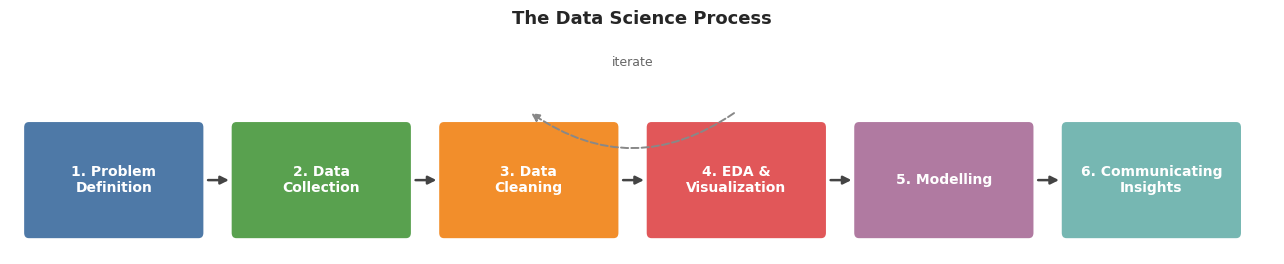

In [2]:
import matplotlib.patches as mpatches

stages = ['1. Problem\nDefinition', '2. Data\nCollection', '3. Data\nCleaning', '4. EDA &\nVisualization',
          '5. Modelling', '6. Communicating\nInsights']
cols = ['#4E79A7', '#59A14F', '#F28E2B', '#E15759', '#B07AA1', '#76B7B2']
fig, ax = plt.subplots(figsize=(13, 2.8))
for i, (s, c) in enumerate(zip(stages, cols)):
    x0 = i * 2.2
    ax.add_patch(mpatches.FancyBboxPatch((x0, 0.2), 1.8, 1.0, boxstyle='round,pad=0.05', fc=c, ec='none'))
    ax.text(x0 + 0.9, 0.7, s, ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    if i < len(stages) - 1:
        ax.annotate('', xy=(x0 + 2.15, 0.7), xytext=(x0 + 1.87, 0.7), arrowprops=dict(arrowstyle='-|>', lw=1.8, color='#444'))
ax.annotate('', xy=(2 * 2.2 + 0.9, 1.35), xytext=(3 * 2.2 + 0.9, 1.35),
            arrowprops=dict(arrowstyle='-|>', lw=1.4, color='#888', connectionstyle='arc3,rad=-0.35', ls='--'))
ax.text(2.5 * 2.2 + 0.9, 1.78, 'iterate', ha='center', fontsize=9, color='#666')
ax.set_xlim(-0.2, 13.2); ax.set_ylim(0, 2.1); ax.axis('off')
ax.set_title('The Data Science Process', fontsize=13, fontweight='bold')
save('fig01_data_science_process')

In [3]:
df = pd.read_csv('data/penguins.csv')
print('Shape (rows, columns):', df.shape)
print('\nFirst 5 rows:')
print(df.head().to_string())
print('\nLast 3 rows:')
print(df.tail(3).to_string())

Shape (rows, columns): (344, 7)

First 5 rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     sex
0  Adelie  Torgersen            39.1           18.7              181.0       3750.0    Male
1  Adelie  Torgersen            39.5           17.4              186.0       3800.0  Female
2  Adelie  Torgersen            40.3           18.0              195.0       3250.0  Female
3  Adelie  Torgersen             NaN            NaN                NaN          NaN     NaN
4  Adelie  Torgersen            36.7           19.3              193.0       3450.0  Female

Last 3 rows:
    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     sex
341  Gentoo  Biscoe            50.4           15.7              222.0       5750.0    Male
342  Gentoo  Biscoe            45.2           14.8              212.0       5200.0  Female
343  Gentoo  Biscoe            49.9           16.1              213.0       5400.0    Male


In [4]:
print('--- df.info() ---')
df.info()
print('\n--- df.describe() ---')
print(df.describe().round(2).to_string())
tbl(df.describe().round(2), 'describe_raw')

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB

--- df.describe() ---
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          342.00         342.00             342.00       342.00
mean            43.92          17.15             200.92      4201.75
std              5.46           1.97              14.06       801.95
min             32.10          13.10             172.00      2700.00
25%             39.22          15.60    

In [5]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cat_cols = ['species', 'island', 'sex']
types = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'unique_values': df.nunique(),
    'example': df.iloc[0].astype(str),
})
types['data_type_category'] = ['Categorical (nominal)', 'Categorical (nominal)', 'Numerical (continuous)',
                               'Numerical (continuous)', 'Numerical (continuous)', 'Numerical (continuous)',
                               'Categorical (binary)']
print(types.to_string())
tbl(types, 'variable_types')
print('\nNumerical columns :', num_cols)
print('Categorical columns:', cat_cols)

                     dtype  unique_values    example      data_type_category
species                str              3     Adelie   Categorical (nominal)
island                 str              3  Torgersen   Categorical (nominal)
bill_length_mm     float64            164       39.1  Numerical (continuous)
bill_depth_mm      float64             80       18.7  Numerical (continuous)
flipper_length_mm  float64             55      181.0  Numerical (continuous)
body_mass_g        float64             94     3750.0  Numerical (continuous)
sex                    str              2       Male    Categorical (binary)

Numerical columns : ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical columns: ['species', 'island', 'sex']


                   missing_count  missing_%
species                        0       0.00
island                         0       0.00
bill_length_mm                 2       0.58
bill_depth_mm                  2       0.58
flipper_length_mm              2       0.58
body_mass_g                    2       0.58
sex                           11       3.20

Rows with at least one missing value: 11
Rows where ALL four measurements are missing: 2

Rows with missing values (sample):
   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  sex
3   Adelie  Torgersen             NaN            NaN                NaN          NaN  NaN
8   Adelie  Torgersen            34.1           18.1              193.0       3475.0  NaN
9   Adelie  Torgersen            42.0           20.2              190.0       4250.0  NaN
10  Adelie  Torgersen            37.8           17.1              186.0       3300.0  NaN
11  Adelie  Torgersen            37.8           17.3              180.0 

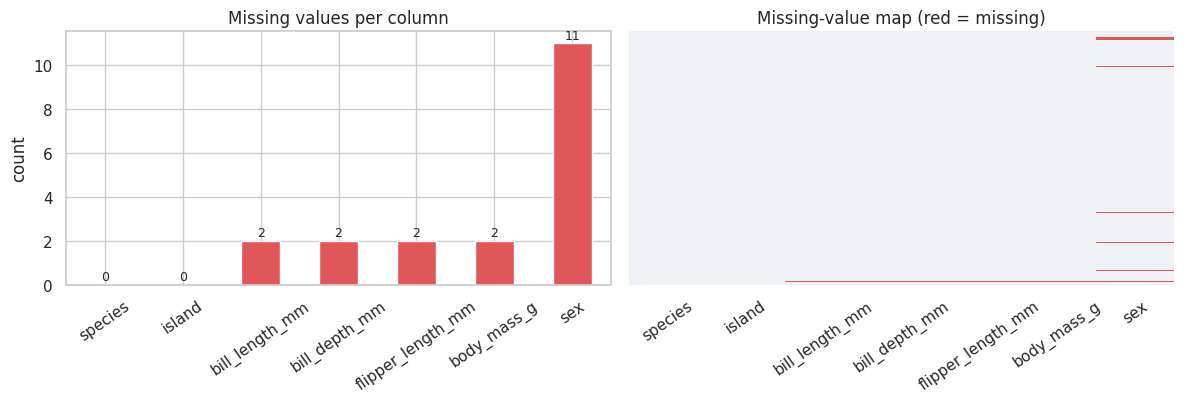

In [6]:
missing = pd.DataFrame({'missing_count': df.isna().sum(), 'missing_%': (df.isna().mean() * 100).round(2)})
print(missing.to_string())
print('\nRows with at least one missing value:', int(df.isna().any(axis=1).sum()))
print('Rows where ALL four measurements are missing:', int(df[num_cols].isna().all(axis=1).sum()))
print('\nRows with missing values (sample):')
print(df[df.isna().any(axis=1)].head(6).to_string())
tbl(missing, 'missing_values')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
missing['missing_count'].plot(kind='bar', ax=axes[0], color='#E15759', edgecolor='white')
axes[0].set_title('Missing values per column'); axes[0].set_ylabel('count'); axes[0].tick_params(axis='x', rotation=35)
for i, v in enumerate(missing['missing_count']):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontsize=9)
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap=['#EEF2F7', '#E15759'], ax=axes[1])
axes[1].set_title('Missing-value map (red = missing)'); axes[1].tick_params(axis='x', rotation=35)
save('fig02_missing_values')

In [7]:
print('Duplicate rows:', df.duplicated().sum())
print('\nUnique labels (checking for typos / inconsistent categories):')
for c in cat_cols:
    print(f'  {c}: {sorted(df[c].dropna().unique())}')
df = df.drop_duplicates()
print('\nShape after drop_duplicates:', df.shape)

Duplicate rows: 0

Unique labels (checking for typos / inconsistent categories):
  species: ['Adelie', 'Chinstrap', 'Gentoo']
  island: ['Biscoe', 'Dream', 'Torgersen']
  sex: ['Female', 'Male']

Shape after drop_duplicates: (344, 7)


In [8]:
# Technique A: group-wise imputation (kept on a COPY to compare).
df_imp = df.copy()
for c in num_cols:
    df_imp[c] = df_imp.groupby('species')[c].transform(lambda s: s.fillna(s.median()))
df_imp['sex'] = df_imp.groupby('species')['sex'].transform(lambda s: s.fillna(s.mode()[0]))
cmp = pd.DataFrame({'mean_before': df[num_cols].mean(), 'mean_after_imputation': df_imp[num_cols].mean()}).round(3)
print('Effect of median imputation on column means:')
print(cmp.to_string())
print('\nMissing after imputation:', int(df_imp.isna().sum().sum()))

# Technique B (used for the rest of the project): drop incomplete rows -> no artificial values.
df_clean = df.dropna().reset_index(drop=True)
print('\nFinal clean dataset shape:', df_clean.shape, '| missing values:', int(df_clean.isna().sum().sum()))
tbl(cmp, 'imputation_comparison')

Effect of median imputation on column means:
                   mean_before  mean_after_imputation
bill_length_mm          43.922                 43.917
bill_depth_mm           17.151                 17.149
flipper_length_mm      200.915                200.927
body_mass_g           4201.754               4202.616

Missing after imputation: 0

Final clean dataset shape: (333, 7) | missing values: 0


In [9]:
enc = df_clean.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
enc['species_code'] = le.fit_transform(enc['species'])
enc['sex_code'] = enc['sex'].map({'Female': 0, 'Male': 1})
enc = pd.concat([enc, pd.get_dummies(enc['island'], prefix='island', dtype=int)], axis=1)
print('Label encoding map:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Sex mapping       : Female=0, Male=1')
print('\nEncoded data (first 5 rows):')
print(enc[['species', 'species_code', 'sex', 'sex_code', 'island', 'island_Biscoe', 'island_Dream',
           'island_Torgersen']].head().to_string())

Label encoding map: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}
Sex mapping       : Female=0, Male=1

Encoded data (first 5 rows):
  species  species_code     sex  sex_code     island  island_Biscoe  island_Dream  island_Torgersen
0  Adelie             0    Male         1  Torgersen              0             0                 1
1  Adelie             0  Female         0  Torgersen              0             0                 1
2  Adelie             0  Female         0  Torgersen              0             0                 1
3  Adelie             0  Female         0  Torgersen              0             0                 1
4  Adelie             0    Male         1  Torgersen              0             0                 1


In [10]:
print('1) .loc  - rows 0-4, selected columns')
print(df_clean.loc[0:4, ['species', 'island', 'body_mass_g']].to_string())
print('\n2) .iloc - rows 10-14, columns 2-4')
print(df_clean.iloc[10:15, 2:5].to_string())
heavy = df_clean[(df_clean.species == 'Gentoo') & (df_clean.body_mass_g > 5500)]
print('\n3) Boolean filter: Gentoo penguins heavier than 5500 g ->', len(heavy), 'rows')
q = df_clean.query('island == "Dream" and sex == "Female"')
print('4) query(): female penguins on Dream island ->', len(q), 'rows')
print('\n5) Random sample (n=4, seed=42)')
print(df_clean.sample(4, random_state=42).to_string())

1) .loc  - rows 0-4, selected columns
  species     island  body_mass_g
0  Adelie  Torgersen       3750.0
1  Adelie  Torgersen       3800.0
2  Adelie  Torgersen       3250.0
3  Adelie  Torgersen       3450.0
4  Adelie  Torgersen       3650.0

2) .iloc - rows 10-14, columns 2-4
    bill_length_mm  bill_depth_mm  flipper_length_mm
10            36.6           17.8              185.0
11            38.7           19.0              195.0
12            42.5           20.7              197.0
13            34.4           18.4              184.0
14            46.0           21.5              194.0

3) Boolean filter: Gentoo penguins heavier than 5500 g -> 28 rows
4) query(): female penguins on Dream island -> 61 rows

5) Random sample (n=4, seed=42)
       species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     sex
25      Adelie      Dream            39.5           16.7              178.0       3250.0  Female
309     Gentoo     Biscoe            46.9           14.

   body_mass_g  mass_log  mass_zscore  mass_minmax mass_class  bill_ratio
0       3750.0     8.230       -0.568        0.292     Medium       2.091
1       3800.0     8.243       -0.506        0.306     Medium       2.270
2       3250.0     8.086       -1.189        0.153      Light       2.239
3       3450.0     8.146       -0.940        0.208      Light       1.902
4       3650.0     8.202       -0.692        0.264      Light       1.908
5       3625.0     8.196       -0.723        0.257      Light       2.185

Mass class counts:
mass_class
Light     113
Medium    110
Heavy     110


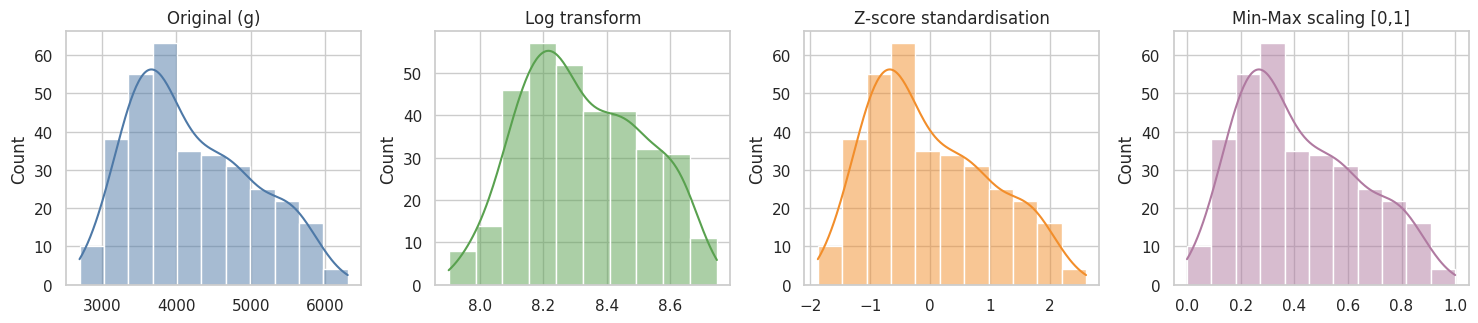

In [11]:
t = df_clean.copy()
t['mass_log'] = np.log(t.body_mass_g)
t['mass_zscore'] = (t.body_mass_g - t.body_mass_g.mean()) / t.body_mass_g.std()
t['mass_minmax'] = (t.body_mass_g - t.body_mass_g.min()) / (t.body_mass_g.max() - t.body_mass_g.min())
t['mass_class'] = pd.qcut(t.body_mass_g, 3, labels=['Light', 'Medium', 'Heavy'])
t['bill_ratio'] = (t.bill_length_mm / t.bill_depth_mm).round(3)
print(t[['body_mass_g', 'mass_log', 'mass_zscore', 'mass_minmax', 'mass_class', 'bill_ratio']].head(6).round(3).to_string())
print('\nMass class counts:')
print(t.mass_class.value_counts().to_string())

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, (c, ttl, col) in zip(axes, [('body_mass_g', 'Original (g)', '#4E79A7'), ('mass_log', 'Log transform', '#59A14F'),
                                    ('mass_zscore', 'Z-score standardisation', '#F28E2B'),
                                    ('mass_minmax', 'Min-Max scaling [0,1]', '#B07AA1')]):
    sns.histplot(t[c], kde=True, color=col, ax=ax); ax.set_title(ttl); ax.set_xlabel('')
save('fig03_transformations')

In [12]:
g1 = df_clean.groupby('species')[num_cols].mean().round(2)
print('Mean of each measurement by species:')
print(g1.to_string())
g2 = df_clean.groupby(['species', 'sex']).agg(count=('body_mass_g', 'size'), mean_mass=('body_mass_g', 'mean'),
                                              std_mass=('body_mass_g', 'std'), max_flipper=('flipper_length_mm', 'max')).round(1)
print('\nMultiple aggregations by species and sex:')
print(g2.to_string())
pv = df_clean.pivot_table(values='body_mass_g', index='species', columns='island', aggfunc='mean').round(1)
print('\nPivot table - mean body mass (g): species x island')
print(pv.to_string())
ct0 = pd.crosstab(df_clean.species, df_clean.island, margins=True)
print('\nCross-tabulation: species x island')
print(ct0.to_string())
tbl(g1, 'groupby_species_mean'); tbl(g2, 'groupby_species_sex'); tbl(pv, 'pivot_mass_species_island')

Mean of each measurement by species:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie              38.82          18.35             190.10      3706.16
Chinstrap           48.83          18.42             195.82      3733.09
Gentoo              47.57          15.00             217.24      5092.44

Multiple aggregations by species and sex:
                  count  mean_mass  std_mass  max_flipper
species   sex                                            
Adelie    Female     73     3368.8     269.4        202.0
          Male       73     4043.5     346.8        210.0
Chinstrap Female     34     3527.2     285.3        202.0
          Male       34     3939.0     362.1        212.0
Gentoo    Female     58     4679.7     281.6        222.0
          Male       61     5484.8     313.2        231.0

Pivot table - mean body mass (g): species x island
island     Biscoe   Dream  Torgersen
sp

# UNIT 2 - Visualizing using Matplotlib

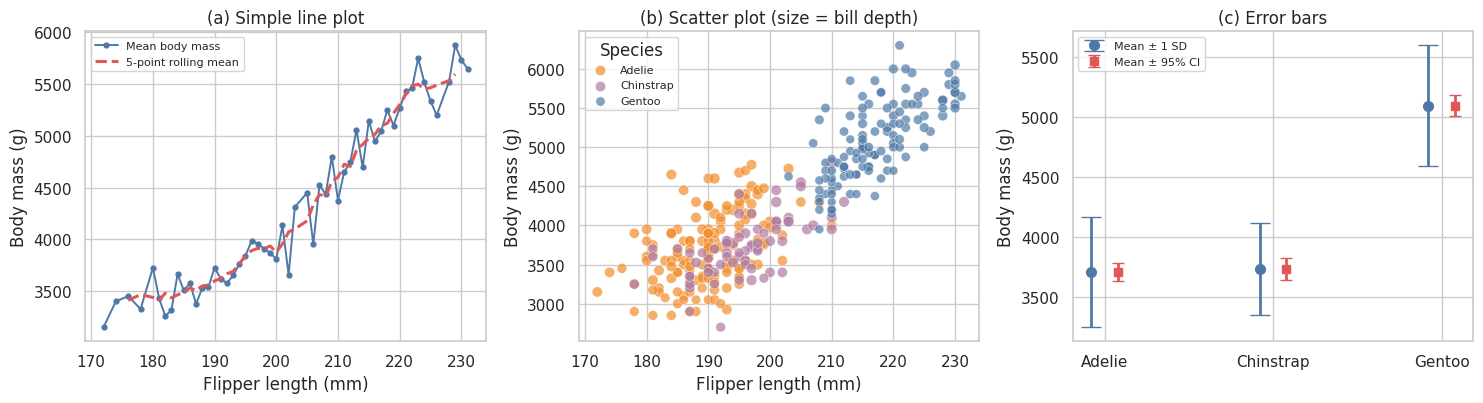

              mean     std    sem
species                          
Adelie     3706.16  458.62  37.96
Chinstrap  3733.09  384.34  46.61
Gentoo     5092.44  501.48  45.97


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) simple line plot
s = df_clean.groupby('flipper_length_mm').body_mass_g.mean()
axes[0].plot(s.index, s.values, color='#4E79A7', marker='o', ms=3.5, lw=1.4, ls='-', label='Mean body mass')
axes[0].plot(s.index, s.rolling(5, center=True).mean(), color='#E15759', lw=2.2, ls='--', label='5-point rolling mean')
axes[0].set(xlabel='Flipper length (mm)', ylabel='Body mass (g)', title='(a) Simple line plot')
axes[0].legend(fontsize=8)

# (b) simple scatter plot
for sp, g in df_clean.groupby('species'):
    axes[1].scatter(g.flipper_length_mm, g.body_mass_g, c=PAL[sp], s=g.bill_depth_mm * 3, alpha=0.7,
                    edgecolor='white', linewidth=0.4, label=sp)
axes[1].set(xlabel='Flipper length (mm)', ylabel='Body mass (g)', title='(b) Scatter plot (size = bill depth)')
axes[1].legend(title='Species', fontsize=8)

# (c) visualizing errors
st = df_clean.groupby('species').body_mass_g.agg(['mean', 'std', 'sem'])
xpos = np.arange(len(st))
axes[2].errorbar(xpos - 0.08, st['mean'], yerr=st['std'], fmt='o', color='#4E79A7', capsize=7, lw=2, ms=7, label='Mean ± 1 SD')
axes[2].errorbar(xpos + 0.08, st['mean'], yerr=1.96 * st['sem'], fmt='s', color='#E15759', capsize=4, lw=2, ms=6, label='Mean ± 95% CI')
axes[2].set_xticks(xpos); axes[2].set_xticklabels(st.index)
axes[2].set(ylabel='Body mass (g)', title='(c) Error bars'); axes[2].legend(fontsize=8)
save('fig04_line_scatter_errorbars')
print(st.round(2).to_string())
tbl(st.round(2), 'mass_mean_std_sem')

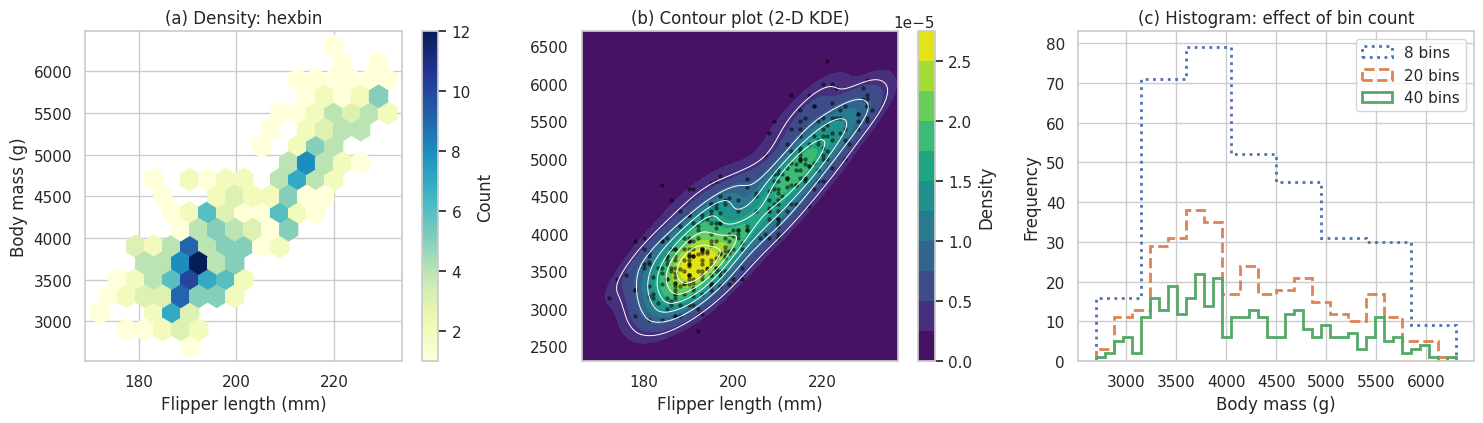

In [14]:
from scipy.stats import gaussian_kde
x = df_clean.flipper_length_mm.values
y = df_clean.body_mass_g.values
xx, yy = np.mgrid[x.min() - 6:x.max() + 6:120j, y.min() - 400:y.max() + 400:120j]
kde = gaussian_kde(np.vstack([x, y]))
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
hb = axes[0].hexbin(x, y, gridsize=16, cmap='YlGnBu', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='Count'); axes[0].set(xlabel='Flipper length (mm)', ylabel='Body mass (g)', title='(a) Density: hexbin')
cf = axes[1].contourf(xx, yy, zz, levels=12, cmap='viridis')
cs = axes[1].contour(xx, yy, zz, levels=6, colors='white', linewidths=0.7)
axes[1].scatter(x, y, s=5, c='black', alpha=0.4)
fig.colorbar(cf, ax=axes[1], label='Density'); axes[1].set(xlabel='Flipper length (mm)', title='(b) Contour plot (2-D KDE)')
for b, ls in [(8, ':'), (20, '--'), (40, '-')]:
    axes[2].hist(y, bins=b, histtype='step', lw=2, ls=ls, label=f'{b} bins')
axes[2].set(xlabel='Body mass (g)', ylabel='Frequency', title='(c) Histogram: effect of bin count'); axes[2].legend()
save('fig05_density_contour_histogram')

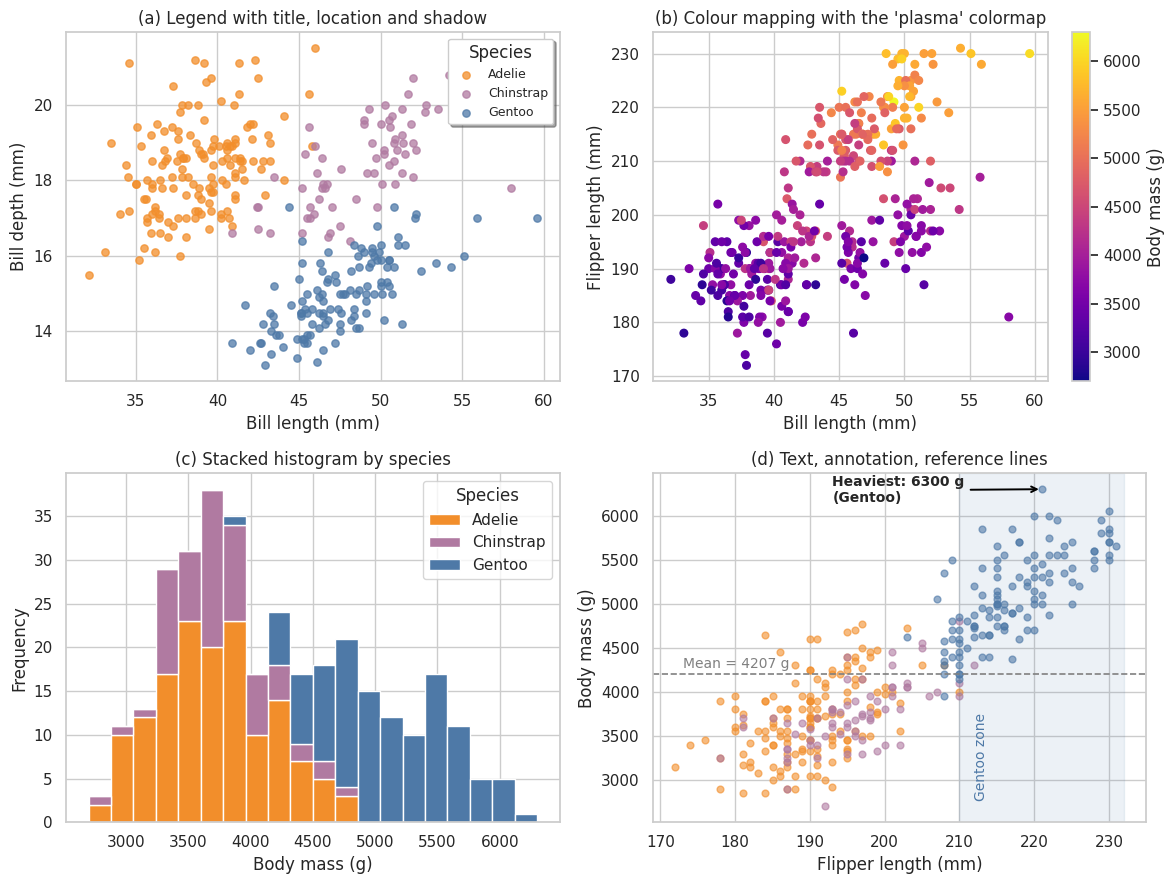

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) legends
for sp, g in df_clean.groupby('species'):
    axes[0, 0].scatter(g.bill_length_mm, g.bill_depth_mm, c=PAL[sp], label=sp, alpha=0.75, s=28)
axes[0, 0].legend(title='Species', loc='upper right', frameon=True, shadow=True, fontsize=9)
axes[0, 0].set(xlabel='Bill length (mm)', ylabel='Bill depth (mm)', title='(a) Legend with title, location and shadow')

# (b) colours / colormap
sc = axes[0, 1].scatter(df_clean.bill_length_mm, df_clean.flipper_length_mm, c=df_clean.body_mass_g, cmap='plasma', s=30)
fig.colorbar(sc, ax=axes[0, 1], label='Body mass (g)')
axes[0, 1].set(xlabel='Bill length (mm)', ylabel='Flipper length (mm)', title="(b) Colour mapping with the 'plasma' colormap")

# (c) stacked histogram with custom colours
axes[1, 0].hist([df_clean[df_clean.species == s].body_mass_g for s in PAL], bins=20, stacked=True,
                color=list(PAL.values()), label=list(PAL.keys()), edgecolor='white')
axes[1, 0].legend(title='Species'); axes[1, 0].set(xlabel='Body mass (g)', ylabel='Frequency', title='(c) Stacked histogram by species')

# (d) text and annotation
ax = axes[1, 1]
for sp, g in df_clean.groupby('species'):
    ax.scatter(g.flipper_length_mm, g.body_mass_g, c=PAL[sp], alpha=0.6, s=24)
top = df_clean.loc[df_clean.body_mass_g.idxmax()]
ax.annotate(f'Heaviest: {int(top.body_mass_g)} g\n({top.species})', xy=(top.flipper_length_mm, top.body_mass_g),
            xytext=(top.flipper_length_mm - 28, top.body_mass_g - 150),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.4), fontsize=10, fontweight='bold')
ax.axhline(df_clean.body_mass_g.mean(), color='gray', ls='--', lw=1.2)
ax.text(173, df_clean.body_mass_g.mean() + 60, f'Mean = {df_clean.body_mass_g.mean():.0f} g', color='gray', fontsize=10)
ax.axvspan(210, 232, color='#4E79A7', alpha=0.1)
ax.text(212, 2800, 'Gentoo zone', color='#4E79A7', fontsize=10, rotation=90)
ax.set(xlabel='Flipper length (mm)', ylabel='Body mass (g)', title='(d) Text, annotation, reference lines')
save('fig06_legends_colors_annotation')

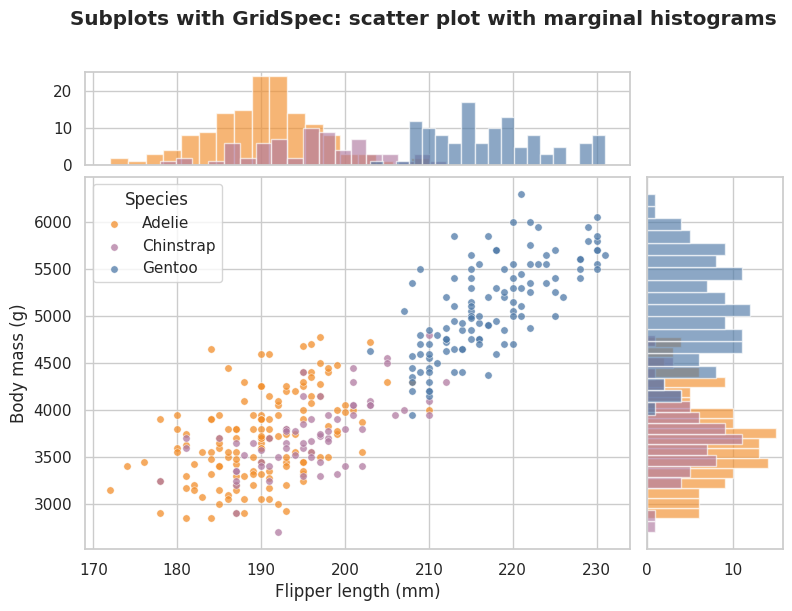

In [16]:
fig = plt.figure(figsize=(9, 6.2))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), hspace=0.05, wspace=0.05)
ax = fig.add_subplot(gs[1, 0]); axt = fig.add_subplot(gs[0, 0], sharex=ax); axr = fig.add_subplot(gs[1, 1], sharey=ax)
for sp, g in df_clean.groupby('species'):
    ax.scatter(g.flipper_length_mm, g.body_mass_g, c=PAL[sp], label=sp, alpha=0.75, s=28, edgecolor='white', linewidth=0.4)
    axt.hist(g.flipper_length_mm, bins=18, color=PAL[sp], alpha=0.65)
    axr.hist(g.body_mass_g, bins=18, color=PAL[sp], alpha=0.65, orientation='horizontal')
axt.tick_params(labelbottom=False); axr.tick_params(labelleft=False)
ax.set(xlabel='Flipper length (mm)', ylabel='Body mass (g)'); ax.legend(title='Species', loc='upper left')
fig.suptitle('Subplots with GridSpec: scatter plot with marginal histograms', fontweight='bold')
save('fig07_subplots_gridspec', tight=False)

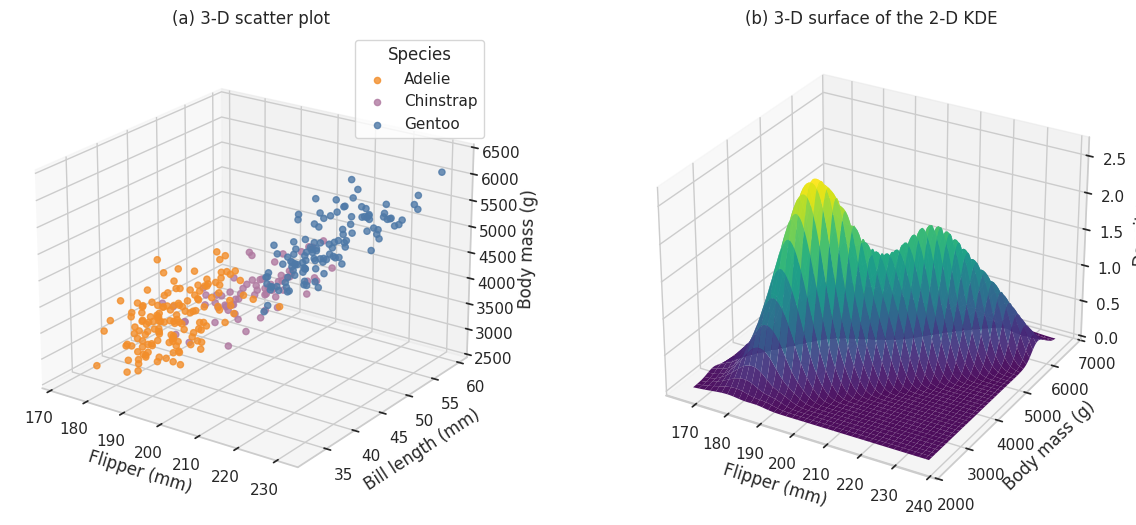

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(13, 5.4))
a1 = fig.add_subplot(121, projection='3d')
for sp, g in df_clean.groupby('species'):
    a1.scatter(g.flipper_length_mm, g.bill_length_mm, g.body_mass_g, c=PAL[sp], label=sp, s=20, alpha=0.8)
a1.set_xlabel('Flipper (mm)'); a1.set_ylabel('Bill length (mm)'); a1.set_zlabel('Body mass (g)')
a1.set_title('(a) 3-D scatter plot'); a1.legend(title='Species'); a1.view_init(elev=22, azim=-55)
a2 = fig.add_subplot(122, projection='3d')
a2.plot_surface(xx, yy, zz, cmap='viridis', edgecolor='none', alpha=0.95)
a2.set_xlabel('Flipper (mm)'); a2.set_ylabel('Body mass (g)'); a2.set_zlabel('Density')
a2.set_title('(b) 3-D surface of the 2-D KDE'); a2.view_init(elev=28, azim=-60)
save('fig08_three_dimensional')

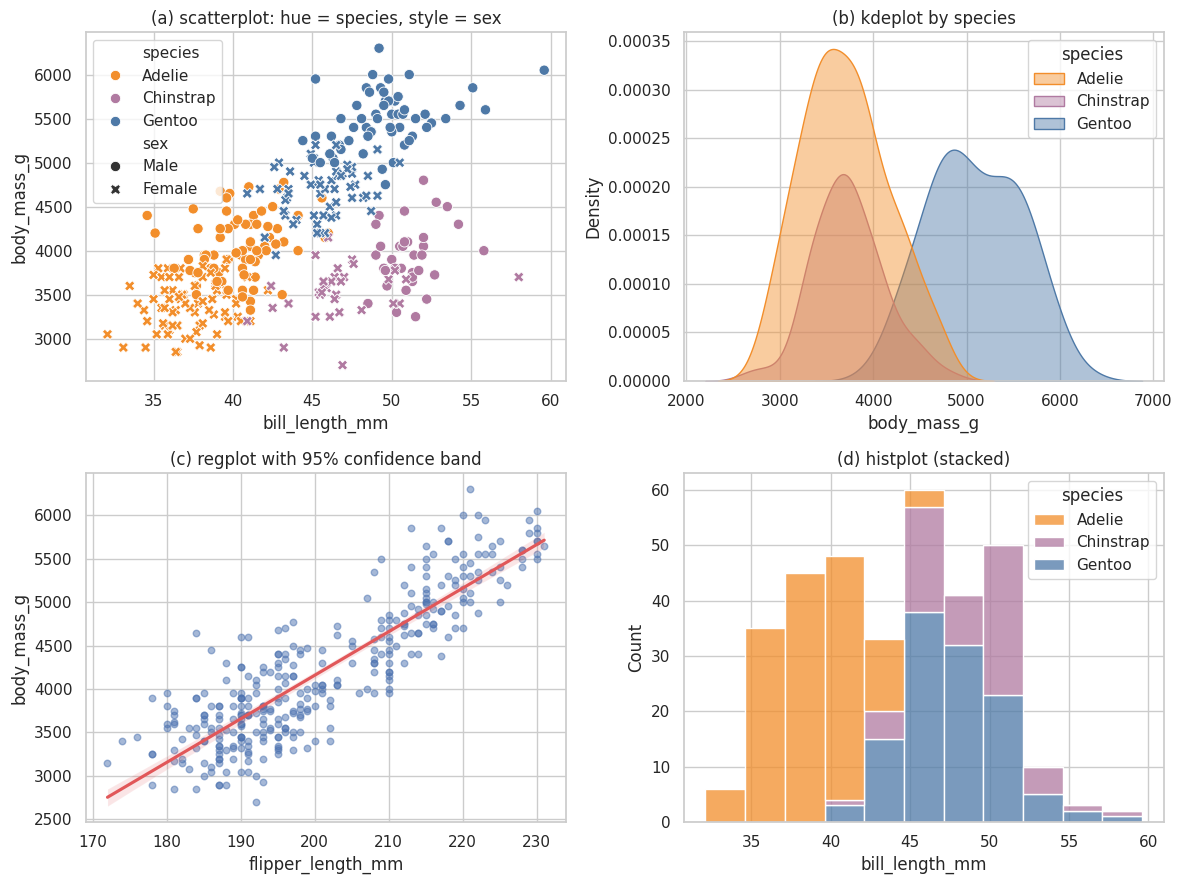

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.scatterplot(data=df_clean, x='bill_length_mm', y='body_mass_g', hue='species', style='sex', palette=PAL, s=55, ax=axes[0, 0])
axes[0, 0].set_title('(a) scatterplot: hue = species, style = sex')
sns.kdeplot(data=df_clean, x='body_mass_g', hue='species', fill=True, palette=PAL, alpha=0.45, ax=axes[0, 1])
axes[0, 1].set_title('(b) kdeplot by species')
sns.regplot(data=df_clean, x='flipper_length_mm', y='body_mass_g', scatter_kws=dict(alpha=0.5, s=22), line_kws=dict(color='#E15759'), ax=axes[1, 0])
axes[1, 0].set_title('(c) regplot with 95% confidence band')
sns.histplot(data=df_clean, x='bill_length_mm', hue='species', multiple='stack', palette=PAL, ax=axes[1, 1])
axes[1, 1].set_title('(d) histplot (stacked)')
save('fig09_seaborn')

In [19]:
import plotly.express as px
fig_px = px.scatter(df_clean, x='flipper_length_mm', y='body_mass_g', color='species', symbol='sex', size='bill_depth_mm',
                    hover_data=['island', 'bill_length_mm'], marginal_x='box', marginal_y='violin',
                    color_discrete_map=PAL, title='Plotly: interactive scatter with marginal box and violin plots',
                    template='plotly_white')
fig_px.write_html('outputs/interactive/plotly_scatter.html')
fig_px.write_image('figures/fig10_plotly_scatter.png', width=1100, height=620, scale=2)
fig3d = px.scatter_3d(df_clean, x='flipper_length_mm', y='bill_length_mm', z='body_mass_g', color='species',
                      color_discrete_map=PAL, title='Plotly: interactive 3-D scatter', template='plotly_white')
fig3d.write_html('outputs/interactive/plotly_3d.html')
print('Saved: figures/fig10_plotly_scatter.png, outputs/interactive/plotly_scatter.html, outputs/interactive/plotly_3d.html')

Saved: figures/fig10_plotly_scatter.png, outputs/interactive/plotly_scatter.html, outputs/interactive/plotly_3d.html


In [20]:
from bokeh.plotting import figure, output_file, save as bokeh_save
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.transform import factor_cmap

src = ColumnDataSource(df_clean)
p = figure(width=760, height=480, title='Bokeh: interactive scatter (hover, zoom, pan)',
           x_axis_label='Flipper length (mm)', y_axis_label='Body mass (g)',
           tools='pan,wheel_zoom,box_zoom,reset,save')
p.scatter('flipper_length_mm', 'body_mass_g', source=src, size=8, alpha=0.8, legend_field='species',
          fill_color=factor_cmap('species', palette=list(PAL.values()), factors=list(PAL.keys())), line_color='white')
p.add_tools(HoverTool(tooltips=[('Species', '@species'), ('Island', '@island'), ('Sex', '@sex'),
                                ('Mass (g)', '@body_mass_g'), ('Flipper (mm)', '@flipper_length_mm')]))
p.legend.location = 'top_left'
output_file('outputs/interactive/bokeh_scatter.html', title='Bokeh penguins')
bokeh_save(p)
print('Saved: outputs/interactive/bokeh_scatter.html (open in a browser)')

Saved: outputs/interactive/bokeh_scatter.html (open in a browser)


# UNIT 3 - Univariate Analysis

In [21]:
d = df_clean[num_cols]
summ = d.agg(['count', 'mean', 'median', 'std', 'var', 'min', 'max']).T
summ['Q1'] = d.quantile(0.25); summ['Q3'] = d.quantile(0.75)
summ['IQR'] = summ['Q3'] - summ['Q1']; summ['range'] = summ['max'] - summ['min']
summ['skewness'] = d.skew(); summ['kurtosis'] = d.kurt()
print(summ.round(2).to_string())
tbl(summ.round(2), 'univariate_summary')


def skew_label(v):
    return 'approximately symmetric' if abs(v) < 0.5 else ('moderately skewed' if abs(v) < 1 else 'highly skewed')


print('\nSkewness interpretation:')
for c in num_cols:
    sk = d[c].skew()
    print(f'  {c:20s} skew = {sk:6.3f} -> {skew_label(sk)} ({"right" if sk > 0 else "left"} tail)')

                   count     mean  median     std        var     min     max      Q1      Q3     IQR   range  skewness  kurtosis
bill_length_mm     333.0    43.99    44.5    5.47      29.91    32.1    59.6    39.5    48.6     9.1    27.5      0.05     -0.88
bill_depth_mm      333.0    17.16    17.3    1.97       3.88    13.1    21.5    15.6    18.7     3.1     8.4     -0.15     -0.89
flipper_length_mm  333.0   200.97   197.0   14.02     196.44   172.0   231.0   190.0   213.0    23.0    59.0      0.36     -0.96
body_mass_g        333.0  4207.06  4050.0  805.22  648372.49  2700.0  6300.0  3550.0  4775.0  1225.0  3600.0      0.47     -0.73

Skewness interpretation:
  bill_length_mm       skew =  0.045 -> approximately symmetric (right tail)
  bill_depth_mm        skew = -0.150 -> approximately symmetric (left tail)
  flipper_length_mm    skew =  0.360 -> approximately symmetric (right tail)
  body_mass_g          skew =  0.472 -> approximately symmetric (right tail)


In [22]:
rows = []
for c in num_cols:
    q1, q3 = d[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = np.abs(stats.zscore(d[c]))
    rows.append(dict(variable=c, lower_fence=round(lo, 2), upper_fence=round(hi, 2),
                     outliers_IQR=int(((d[c] < lo) | (d[c] > hi)).sum()), outliers_zscore_gt3=int((z > 3).sum()),
                     shapiro_p=round(stats.shapiro(d[c])[1], 5)))
out_tbl = pd.DataFrame(rows)
print(out_tbl.to_string(index=False))
tbl(out_tbl, 'outlier_detection', index=False)

         variable  lower_fence  upper_fence  outliers_IQR  outliers_zscore_gt3  shapiro_p
   bill_length_mm        25.85        62.25             0                    0    0.00001
    bill_depth_mm        10.95        23.35             0                    0    0.00001
flipper_length_mm       155.50       247.50             0                    0    0.00000
      body_mass_g      1712.50      6612.50             0                    0    0.00000


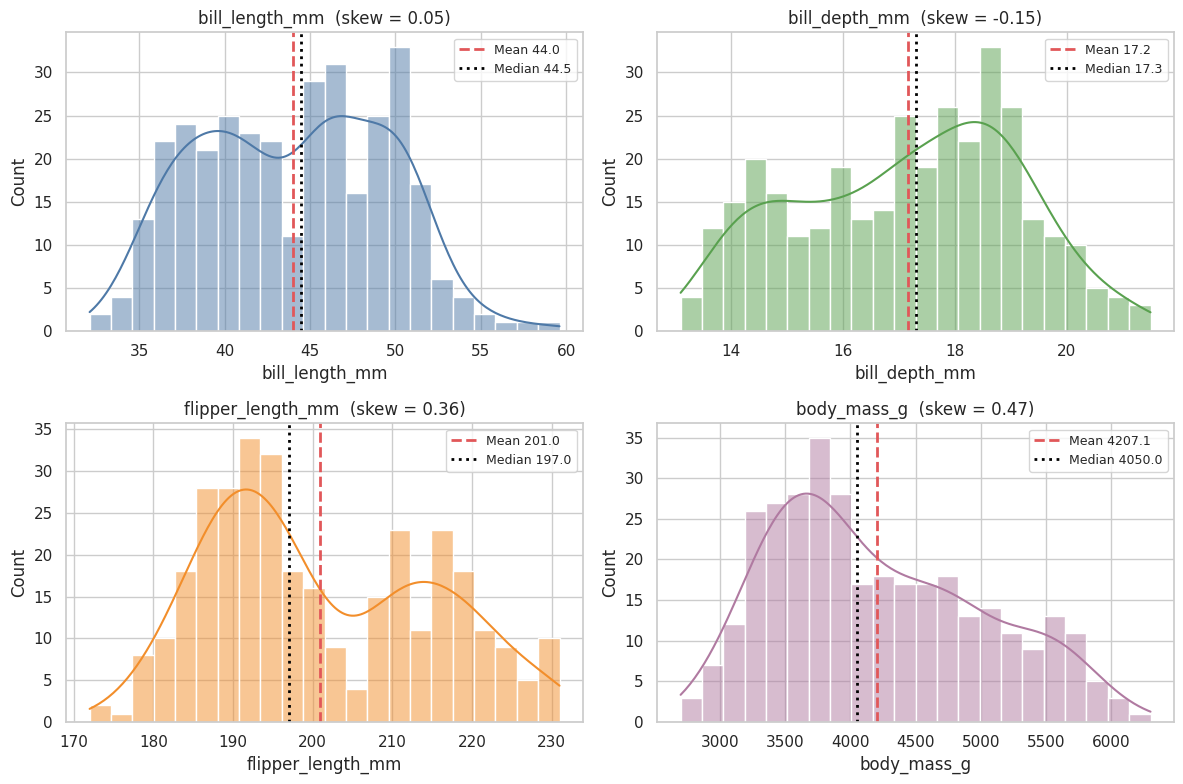

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#4E79A7', '#59A14F', '#F28E2B', '#B07AA1']
for ax, c, col in zip(axes.ravel(), num_cols, colors):
    sns.histplot(d[c], kde=True, color=col, bins=22, ax=ax)
    ax.axvline(d[c].mean(), color='#E15759', ls='--', lw=2, label=f'Mean {d[c].mean():.1f}')
    ax.axvline(d[c].median(), color='black', ls=':', lw=2, label=f'Median {d[c].median():.1f}')
    ax.set_title(f'{c}  (skew = {d[c].skew():.2f})'); ax.legend(fontsize=9)
save('fig11_univariate_histograms')

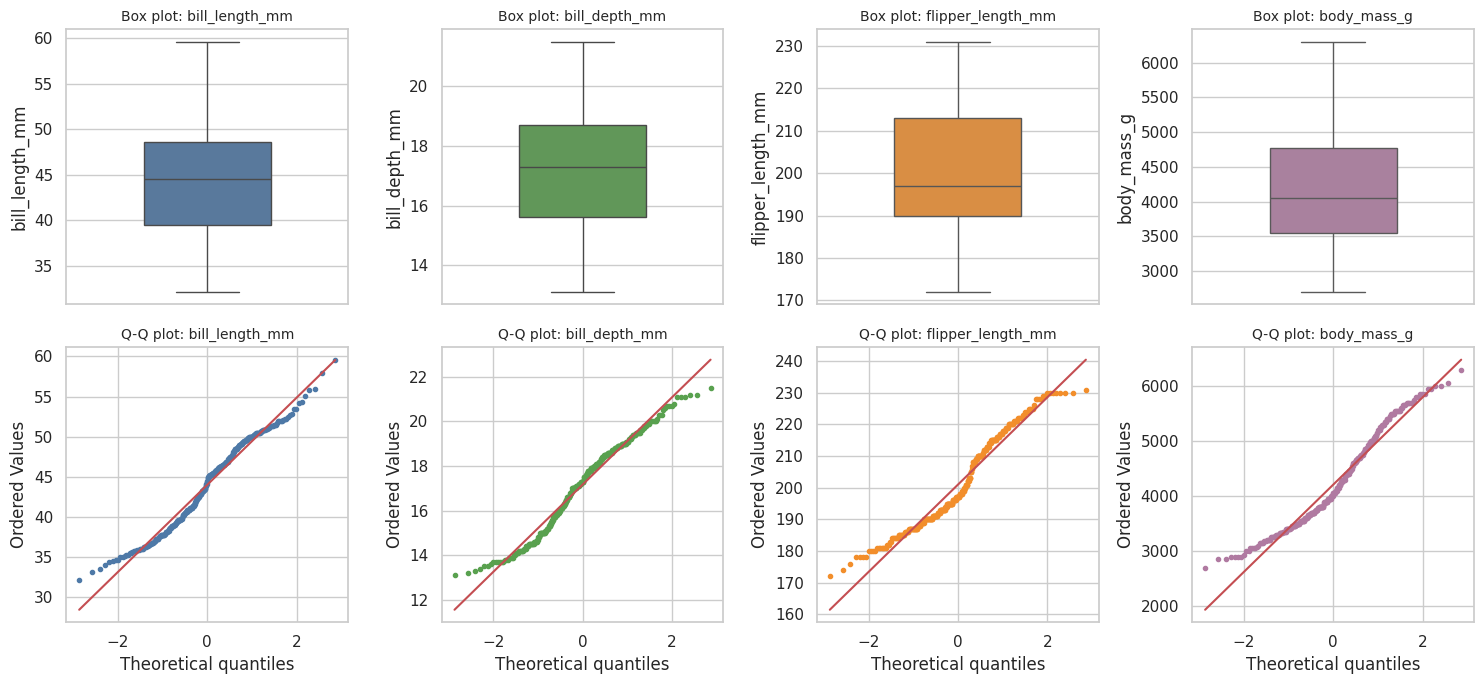

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, (c, col) in enumerate(zip(num_cols, colors)):
    sns.boxplot(y=d[c], color=col, width=0.45, ax=axes[0, i]); axes[0, i].set_title(f'Box plot: {c}', fontsize=10)
    stats.probplot(d[c], dist='norm', plot=axes[1, i])
    axes[1, i].get_lines()[0].set(markersize=3, markerfacecolor=col, markeredgecolor=col)
    axes[1, i].set_title(f'Q-Q plot: {c}', fontsize=10)
save('fig12_boxplots_qq')

Frequency table - species
           count  percent  cumulative_%
species                                
Adelie       146     43.8          43.8
Gentoo       119     35.7          79.5
Chinstrap     68     20.4          99.9

Frequency table - island
           count  percent  cumulative_%
island                                 
Biscoe       163     48.9          48.9
Dream        123     36.9          85.8
Torgersen     47     14.1          99.9

Frequency table - sex
        count  percent  cumulative_%
sex                                 
Male      168     50.5          50.5
Female    165     49.5         100.0



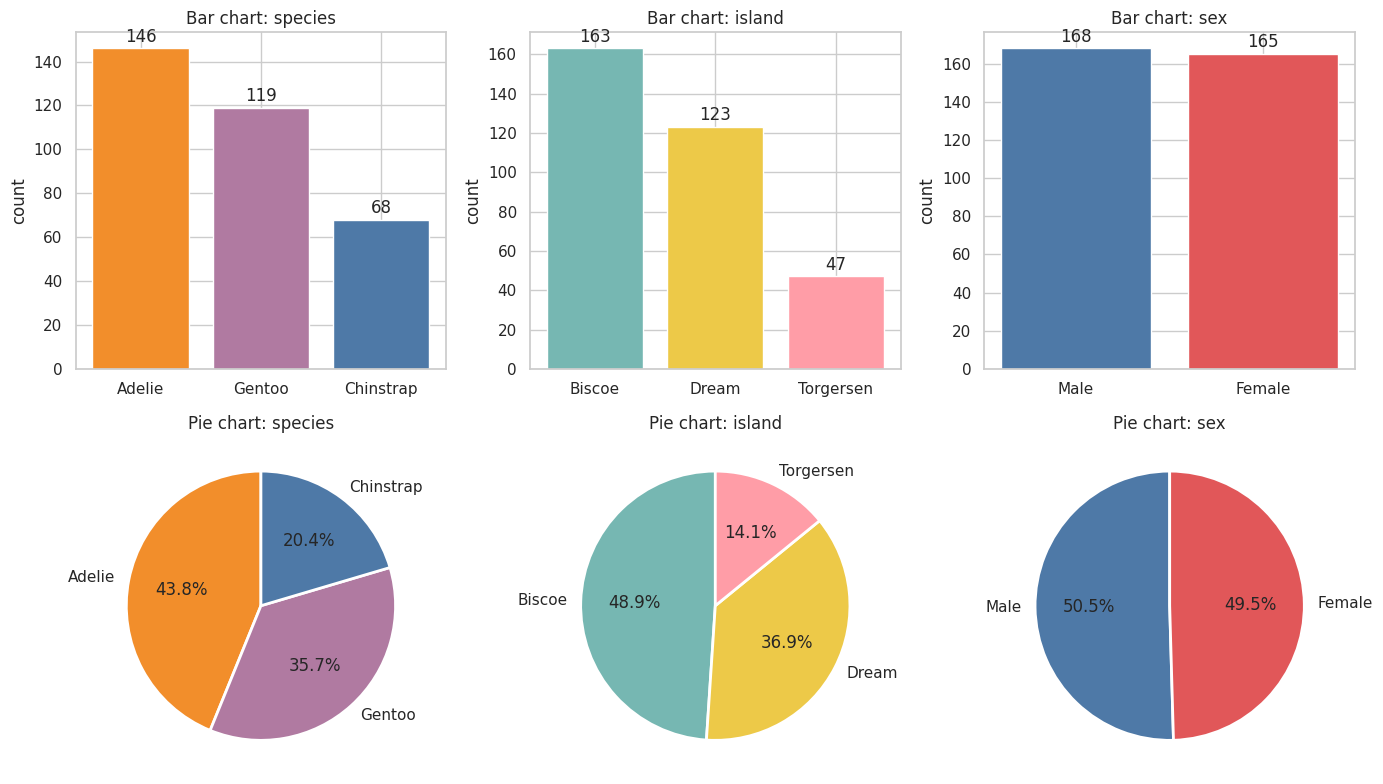

In [25]:
for c in cat_cols:
    f = df_clean[c].value_counts().to_frame('count')
    f['percent'] = (f['count'] / f['count'].sum() * 100).round(1)
    f['cumulative_%'] = f['percent'].cumsum().round(1)
    print(f'Frequency table - {c}')
    print(f.to_string()); print()
    tbl(f, f'freq_{c}')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
palettes = [list(PAL.values()), ['#76B7B2', '#EDC948', '#FF9DA7'], ['#4E79A7', '#E15759']]
for i, (c, pc) in enumerate(zip(cat_cols, palettes)):
    vc = df_clean[c].value_counts()
    bars = axes[0, i].bar(vc.index, vc.values, color=pc[:len(vc)], edgecolor='white')
    axes[0, i].bar_label(bars, padding=2); axes[0, i].set_title(f'Bar chart: {c}'); axes[0, i].set_ylabel('count')
    axes[1, i].pie(vc.values, labels=vc.index, autopct='%1.1f%%', colors=pc[:len(vc)], startangle=90,
                   wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[1, i].set_title(f'Pie chart: {c}')
save('fig13_categorical_bar_pie')

# UNIT 4 - Bivariate Analysis

In [26]:
from itertools import combinations
rows = []
for a, b in combinations(num_cols, 2):
    r, p = stats.pearsonr(df_clean[a], df_clean[b]); rho, ps = stats.spearmanr(df_clean[a], df_clean[b])
    rows.append(dict(variable_1=a, variable_2=b, pearson_r=round(r, 3), pearson_p=f'{p:.2e}',
                     spearman_rho=round(rho, 3), spearman_p=f'{ps:.2e}'))
corr_tbl = pd.DataFrame(rows)
print(corr_tbl.to_string(index=False))
tbl(corr_tbl, 'correlation_pearson_spearman', index=False)

print('\nSimpson\'s paradox check: bill length vs bill depth')
print(f'  Overall Pearson r = {df_clean.bill_length_mm.corr(df_clean.bill_depth_mm):.3f}')
for sp, g in df_clean.groupby('species'):
    print(f'  Within {sp:10s} r = {g.bill_length_mm.corr(g.bill_depth_mm):.3f}')

       variable_1        variable_2  pearson_r pearson_p  spearman_rho spearman_p
   bill_length_mm     bill_depth_mm     -0.229  2.53e-05        -0.214   8.37e-05
   bill_length_mm flipper_length_mm      0.653  7.21e-42         0.670   1.07e-44
   bill_length_mm       body_mass_g      0.589  1.54e-32         0.576   6.97e-31
    bill_depth_mm flipper_length_mm     -0.578  4.78e-31        -0.517   3.46e-24
    bill_depth_mm       body_mass_g     -0.472  7.02e-20        -0.429   2.31e-16
flipper_length_mm       body_mass_g      0.873 3.13e-105         0.840   4.63e-90

Simpson's paradox check: bill length vs bill depth
  Overall Pearson r = -0.229
  Within Adelie     r = 0.386
  Within Chinstrap  r = 0.654
  Within Gentoo     r = 0.654


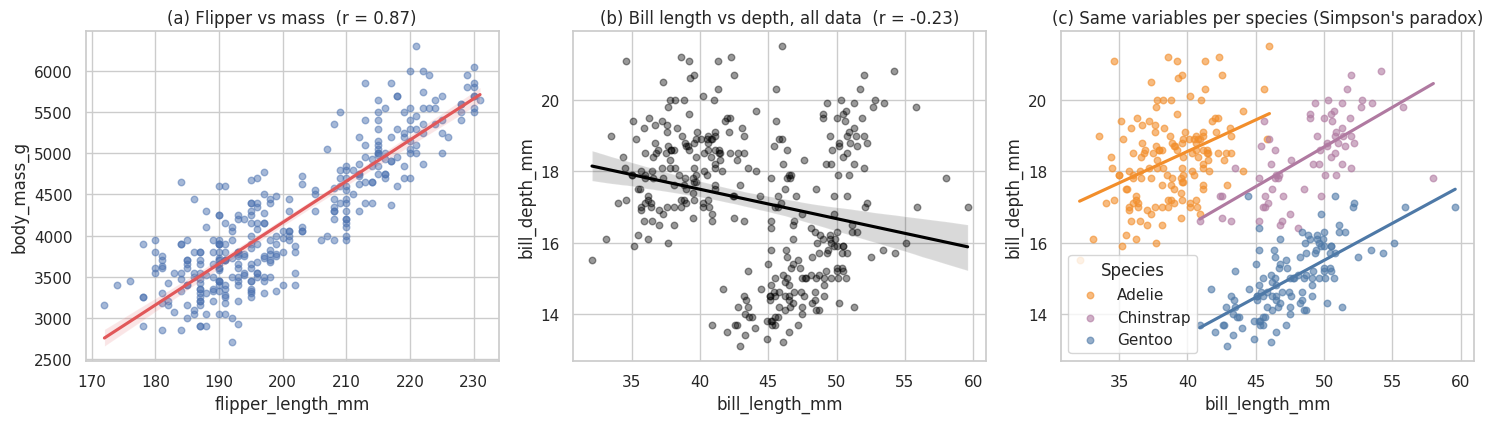

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
sns.regplot(data=df_clean, x='flipper_length_mm', y='body_mass_g', scatter_kws=dict(alpha=0.5, s=22), line_kws=dict(color='#E15759'), ax=axes[0])
axes[0].set_title(f'(a) Flipper vs mass  (r = {df_clean.flipper_length_mm.corr(df_clean.body_mass_g):.2f})')
sns.regplot(data=df_clean, x='bill_length_mm', y='bill_depth_mm', color='black', scatter_kws=dict(alpha=0.4, s=22), ax=axes[1])
axes[1].set_title(f'(b) Bill length vs depth, all data  (r = {df_clean.bill_length_mm.corr(df_clean.bill_depth_mm):.2f})')
for sp, g in df_clean.groupby('species'):
    sns.regplot(data=g, x='bill_length_mm', y='bill_depth_mm', color=PAL[sp], ci=None, scatter_kws=dict(alpha=0.6, s=22), label=sp, ax=axes[2])
axes[2].legend(title='Species'); axes[2].set_title("(c) Same variables per species (Simpson's paradox)")
save('fig14_scatter_correlation')

Species x Island
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     55         47
Chinstrap       0     68          0
Gentoo        119      0          0

Species x Sex
sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61

Chi-square (species vs island): chi2 = 284.59, dof = 4, p = 2.28e-60, Cramer's V = 0.654
Chi-square (species vs sex)   : chi2 = 0.05, dof = 2, p = 0.976


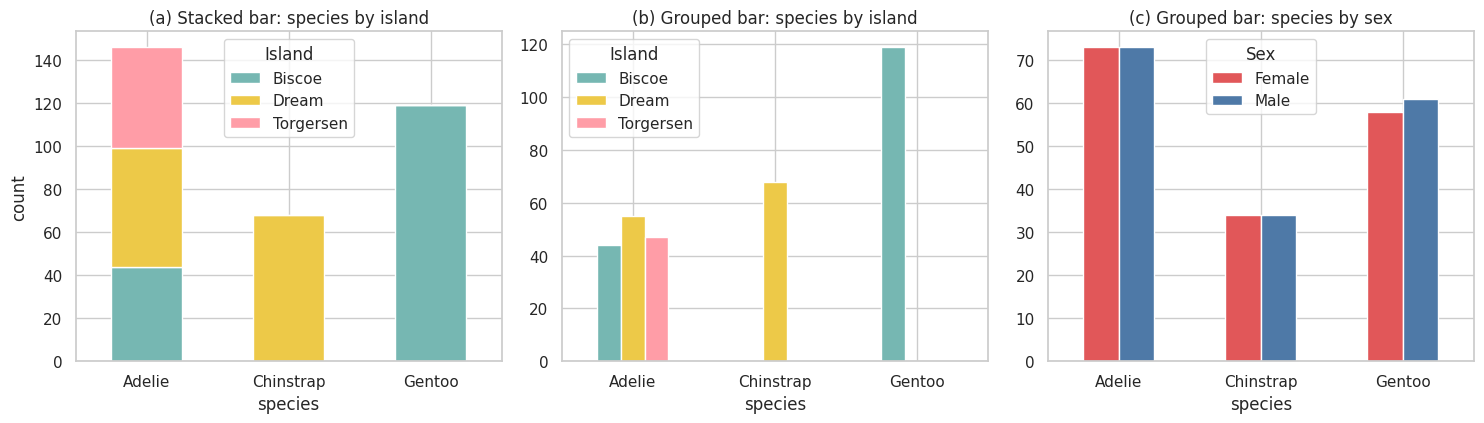

In [28]:
ct = pd.crosstab(df_clean.species, df_clean.island)
ct_sex = pd.crosstab(df_clean.species, df_clean.sex)
print('Species x Island'); print(ct.to_string())
print('\nSpecies x Sex'); print(ct_sex.to_string())
chi2, p, dof, _ = stats.chi2_contingency(ct)
cramers = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f'\nChi-square (species vs island): chi2 = {chi2:.2f}, dof = {dof}, p = {p:.2e}, Cramer\'s V = {cramers:.3f}')
chi2b, pb, dofb, _ = stats.chi2_contingency(ct_sex)
print(f'Chi-square (species vs sex)   : chi2 = {chi2b:.2f}, dof = {dofb}, p = {pb:.3f}')
tbl(ct, 'crosstab_species_island'); tbl(ct_sex, 'crosstab_species_sex')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#76B7B2', '#EDC948', '#FF9DA7'], edgecolor='white', rot=0)
axes[0].set_title('(a) Stacked bar: species by island'); axes[0].set_ylabel('count'); axes[0].legend(title='Island')
ct.plot(kind='bar', ax=axes[1], color=['#76B7B2', '#EDC948', '#FF9DA7'], edgecolor='white', rot=0)
axes[1].set_title('(b) Grouped bar: species by island'); axes[1].legend(title='Island')
ct_sex.plot(kind='bar', ax=axes[2], color=['#E15759', '#4E79A7'], edgecolor='white', rot=0)
axes[2].set_title('(c) Grouped bar: species by sex'); axes[2].legend(title='Sex')
save('fig15_categorical_bivariate')

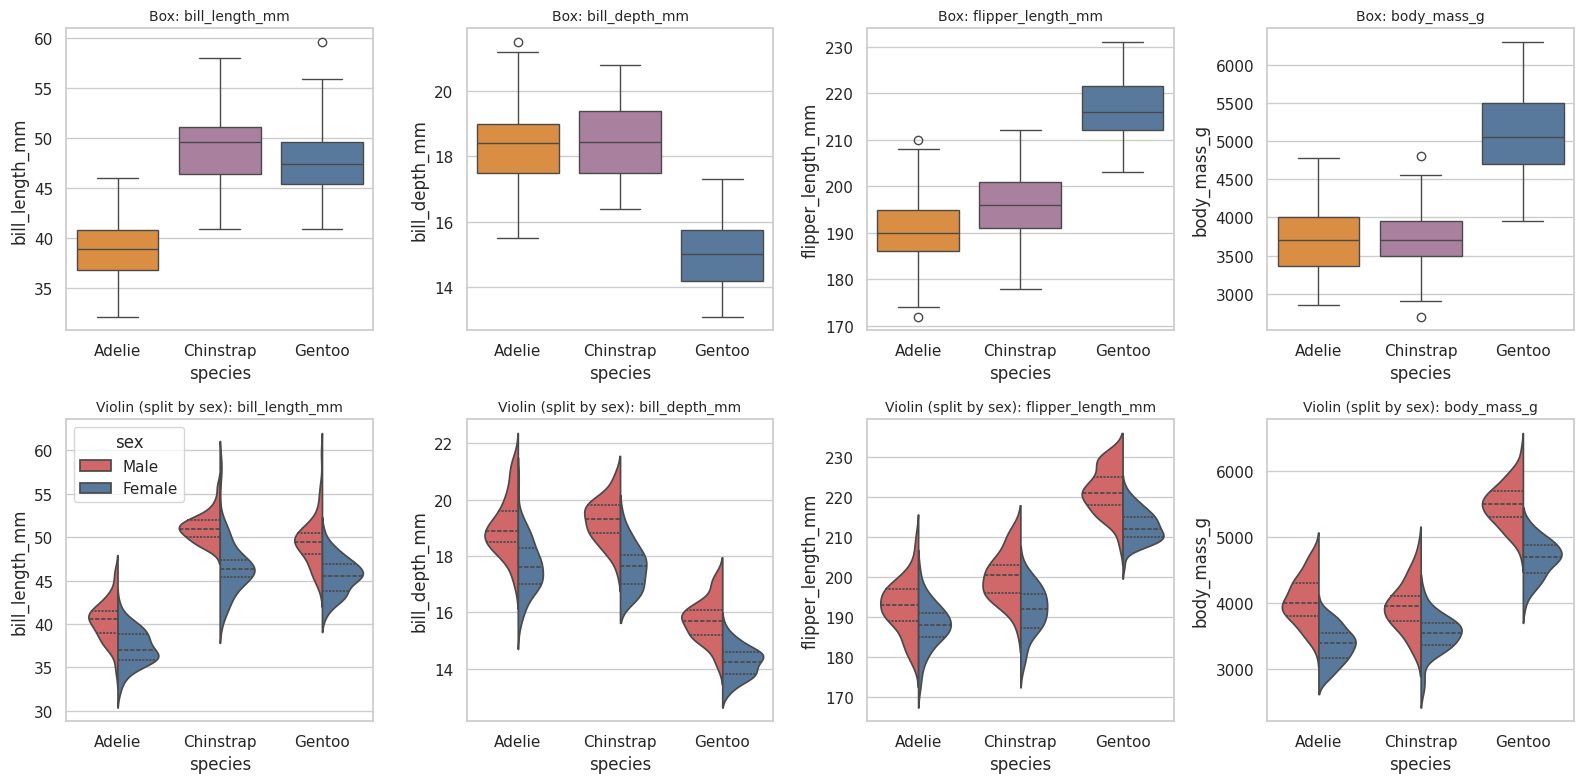

One-way ANOVA across species:
         variable  F_statistic   p_value  eta_squared
   bill_length_mm        397.3  1.38e-88        0.707
    bill_depth_mm        344.8  1.45e-81        0.676
flipper_length_mm        567.4 1.59e-107        0.775
      body_mass_g        341.9  3.74e-81        0.674

Tukey HSD on body mass (0 = Adelie, 1 = Chinstrap, 2 = Gentoo):
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -26.924     0.916  -186.201   132.353
 (0 - 2)  -1386.273     0.000 -1520.255 -1252.290
 (1 - 0)     26.924     0.916  -132.353   186.201
 (1 - 2)  -1359.349     0.000 -1524.267 -1194.430
 (2 - 0)   1386.273     0.000  1252.290  1520.255
 (2 - 1)   1359.349     0.000  1194.430  1524.267


Welch t-test, body mass male vs female: t = 8.55, p = 4.79e-16  (means 4546 g vs 3862 g)


In [29]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, c in enumerate(num_cols):
    sns.boxplot(data=df_clean, x='species', y=c, palette=PAL, ax=axes[0, i]); axes[0, i].set_title(f'Box: {c}', fontsize=10)
    sns.violinplot(data=df_clean, x='species', y=c, hue='sex', split=True, inner='quart', palette=['#E15759', '#4E79A7'], ax=axes[1, i])
    axes[1, i].set_title(f'Violin (split by sex): {c}', fontsize=10)
    if i: axes[1, i].legend_.remove()
save('fig16_box_violin')

rows = []
gm_all = df_clean[num_cols]
for c in num_cols:
    groups = [g[c].values for _, g in df_clean.groupby('species')]
    F, pv_ = stats.f_oneway(*groups)
    gm = df_clean[c].mean()
    ssb = sum(len(g) * (g.mean() - gm) ** 2 for g in groups); sst = ((df_clean[c] - gm) ** 2).sum()
    rows.append(dict(variable=c, F_statistic=round(F, 1), p_value=f'{pv_:.2e}', eta_squared=round(ssb / sst, 3)))
anova_tbl = pd.DataFrame(rows)
print('One-way ANOVA across species:')
print(anova_tbl.to_string(index=False))
tbl(anova_tbl, 'anova_species', index=False)
mass_groups = [g.body_mass_g.values for _, g in df_clean.groupby('species')]
print('\nTukey HSD on body mass (0 = Adelie, 1 = Chinstrap, 2 = Gentoo):')
print(stats.tukey_hsd(*mass_groups))
m = df_clean[df_clean.sex == 'Male'].body_mass_g; f_ = df_clean[df_clean.sex == 'Female'].body_mass_g
tt = stats.ttest_ind(m, f_, equal_var=False)
print(f'\nWelch t-test, body mass male vs female: t = {tt.statistic:.2f}, p = {tt.pvalue:.2e}  (means {m.mean():.0f} g vs {f_.mean():.0f} g)')

# UNIT 5 - Multivariate Analysis and Insights

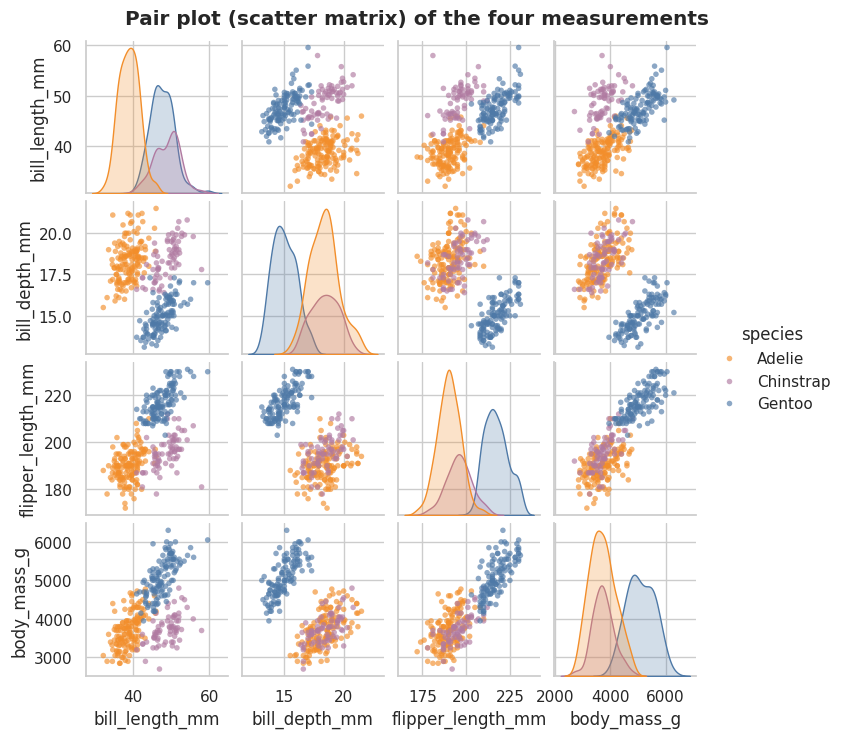

In [30]:
g = sns.pairplot(df_clean, vars=num_cols, hue='species', palette=PAL, diag_kind='kde', height=1.8,
                 plot_kws=dict(alpha=0.65, s=16, edgecolor='none'))
g.fig.suptitle('Pair plot (scatter matrix) of the four measurements', y=1.02, fontweight='bold')
save('fig17_pairplot', g.fig, tight=False)

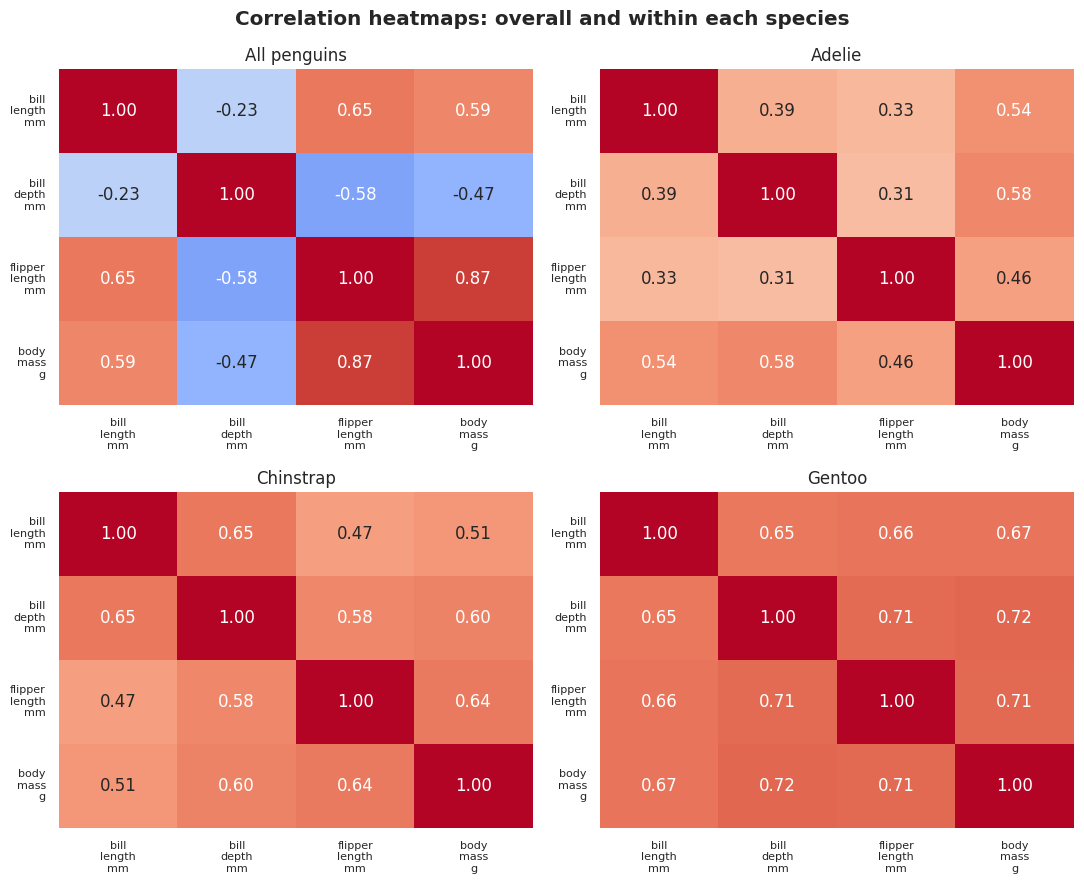

                   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
bill_length_mm              1.000         -0.229              0.653        0.589
bill_depth_mm              -0.229          1.000             -0.578       -0.472
flipper_length_mm           0.653         -0.578              1.000        0.873
body_mass_g                 0.589         -0.472              0.873        1.000


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('All penguins')
for ax, sp in zip([axes[0, 1], axes[1, 0], axes[1, 1]], PAL):
    sns.heatmap(df_clean[df_clean.species == sp][num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, cbar=False)
    ax.set_title(sp)
for ax in axes.ravel():
    ax.set_xticklabels([l.get_text().replace('_', '\n') for l in ax.get_xticklabels()], rotation=0, fontsize=8)
    ax.set_yticklabels([l.get_text().replace('_', '\n') for l in ax.get_yticklabels()], rotation=0, fontsize=8)
fig.suptitle('Correlation heatmaps: overall and within each species', fontweight='bold')
save('fig18_correlation_heatmaps')
print(df_clean[num_cols].corr().round(3).to_string())
tbl(df_clean[num_cols].corr().round(3), 'correlation_matrix')

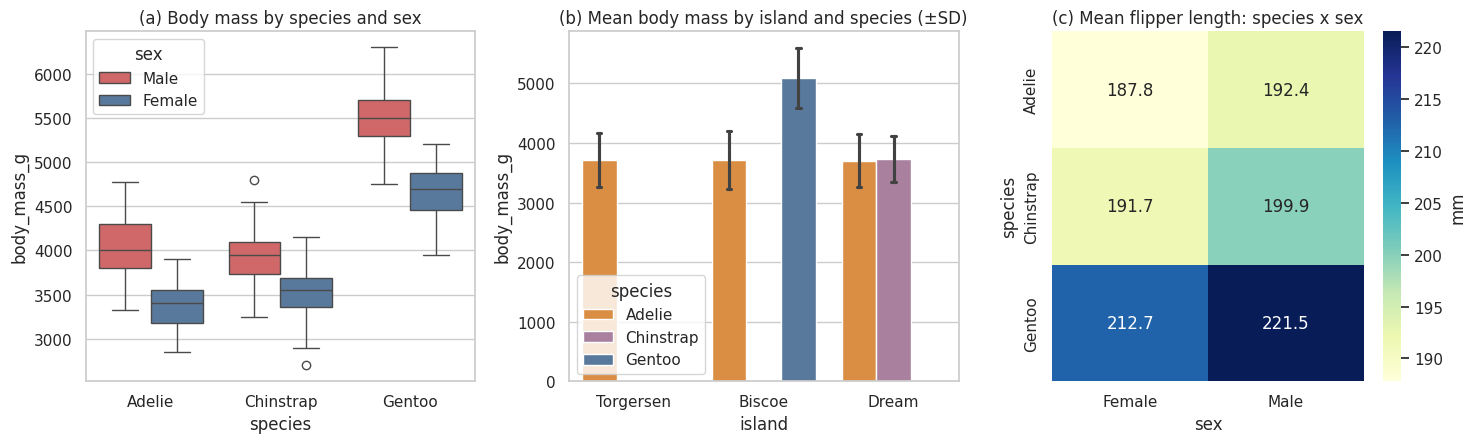

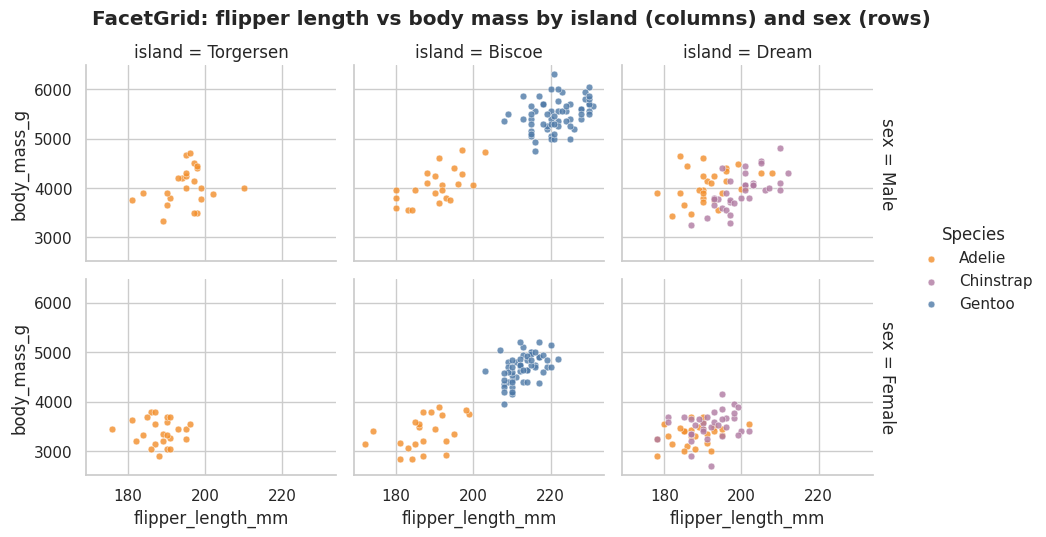

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
sns.boxplot(data=df_clean, x='species', y='body_mass_g', hue='sex', palette=['#E15759', '#4E79A7'], ax=axes[0])
axes[0].set_title('(a) Body mass by species and sex')
sns.barplot(data=df_clean, x='island', y='body_mass_g', hue='species', palette=PAL, errorbar='sd', capsize=0.1, ax=axes[1])
axes[1].set_title('(b) Mean body mass by island and species (±SD)')
pv2 = df_clean.pivot_table(values='flipper_length_mm', index='species', columns='sex', aggfunc='mean')
sns.heatmap(pv2, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[2], cbar_kws=dict(label='mm'))
axes[2].set_title('(c) Mean flipper length: species x sex')
save('fig19_grouped_visualizations')

fg = sns.FacetGrid(df_clean, col='island', row='sex', hue='species', palette=PAL, height=2.6, aspect=1.2, margin_titles=True)
fg.map_dataframe(sns.scatterplot, x='flipper_length_mm', y='body_mass_g', s=24, alpha=0.8)
fg.add_legend(title='Species'); fg.fig.suptitle('FacetGrid: flipper length vs body mass by island (columns) and sex (rows)', y=1.03, fontweight='bold')
save('fig20_facetgrid', fg.fig, tight=False)

Explained variance ratio: [0.6863 0.1945 0.0922 0.027 ] | cumulative: [0.6863 0.8809 0.973  1.    ]

Loadings:
                     PC1    PC2    PC3    PC4
bill_length_mm     0.454  0.600  0.642 -0.145
bill_depth_mm     -0.399  0.796 -0.426  0.160
flipper_length_mm  0.577  0.006 -0.236  0.782
body_mass_g        0.550  0.076 -0.592 -0.585


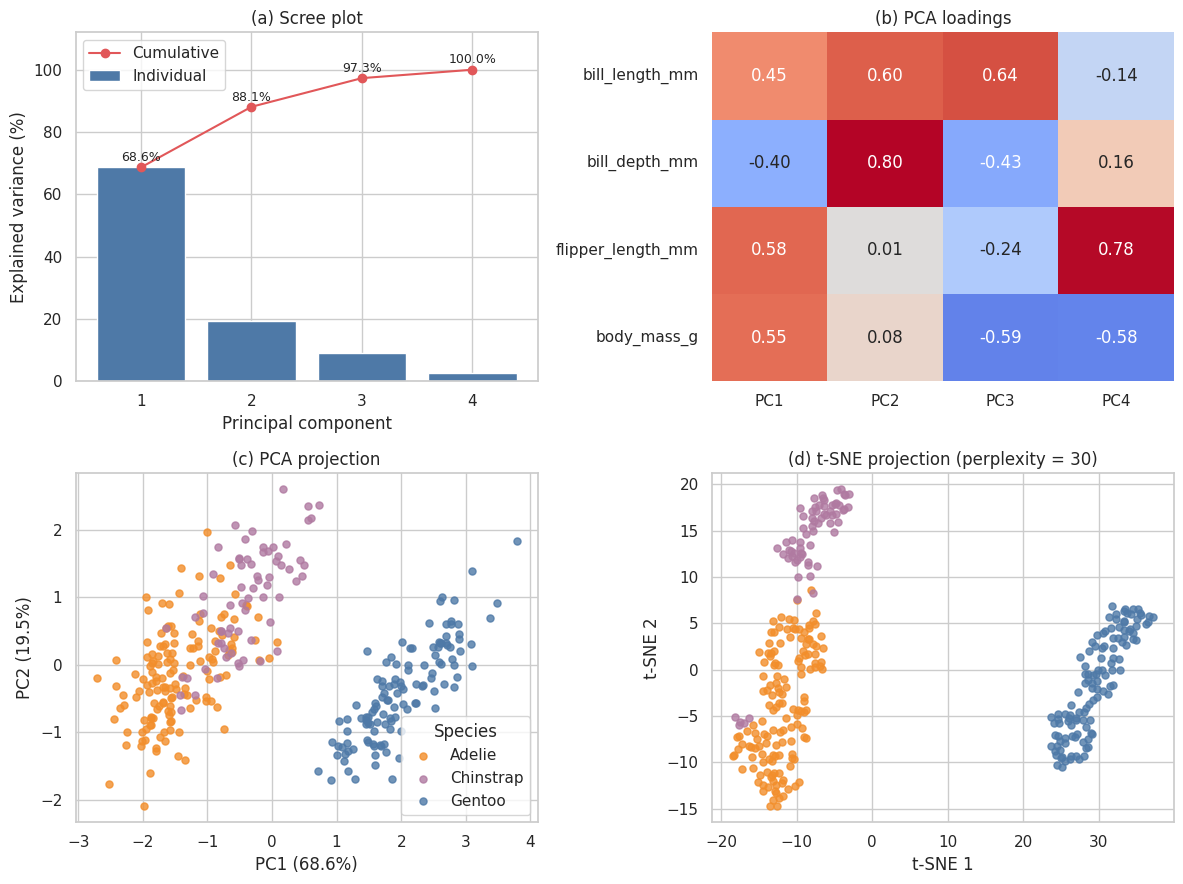

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Xs = StandardScaler().fit_transform(df_clean[num_cols])
pca = PCA(n_components=4).fit(Xs)
evr = pca.explained_variance_ratio_
load = pd.DataFrame(pca.components_.T, index=num_cols, columns=[f'PC{i+1}' for i in range(4)]).round(3)
print('Explained variance ratio:', evr.round(4), '| cumulative:', np.cumsum(evr).round(4))
print('\nLoadings:'); print(load.to_string())
tbl(load, 'pca_loadings')
Z = pca.transform(Xs)
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42).fit_transform(Xs)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0, 0].bar(range(1, 5), evr * 100, color='#4E79A7', label='Individual')
axes[0, 0].plot(range(1, 5), np.cumsum(evr) * 100, 'o-', color='#E15759', label='Cumulative')
for i, v in enumerate(np.cumsum(evr) * 100): axes[0, 0].text(i + 1, v + 2, f'{v:.1f}%', ha='center', fontsize=9)
axes[0, 0].set(xticks=range(1, 5), xlabel='Principal component', ylabel='Explained variance (%)', ylim=(0, 112), title='(a) Scree plot'); axes[0, 0].legend()
sns.heatmap(load, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0, 1], cbar=False); axes[0, 1].set_title('(b) PCA loadings')
for sp in PAL:
    mk = (df_clean.species == sp).values
    axes[1, 0].scatter(Z[mk, 0], Z[mk, 1], c=PAL[sp], label=sp, s=26, alpha=0.8)
    axes[1, 1].scatter(tsne[mk, 0], tsne[mk, 1], c=PAL[sp], label=sp, s=26, alpha=0.8)
axes[1, 0].set(xlabel=f'PC1 ({evr[0]*100:.1f}%)', ylabel=f'PC2 ({evr[1]*100:.1f}%)', title='(c) PCA projection'); axes[1, 0].legend(title='Species')
axes[1, 1].set(xlabel='t-SNE 1', ylabel='t-SNE 2', title='(d) t-SNE projection (perplexity = 30)')
save('fig21_dimensionality_reduction')

Train size: (249, 5) | Test size: (84, 5)


               model  cv_mean  cv_std  test_accuracy
 Logistic Regression   0.9879  0.0160         1.0000
           SVM (RBF)   0.9879  0.0160         1.0000
k-Nearest Neighbours   0.9839  0.0150         1.0000
       Random Forest   0.9838  0.0152         0.9881

Best model by CV accuracy: Logistic Regression
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        37
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      1.00      1.00        30

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Random Forest feature importances:
bill_length_mm       0.402
flipper_length_mm    0.291
bill_depth_mm        0.172
body_mass_g          0.126
sex                  0.009


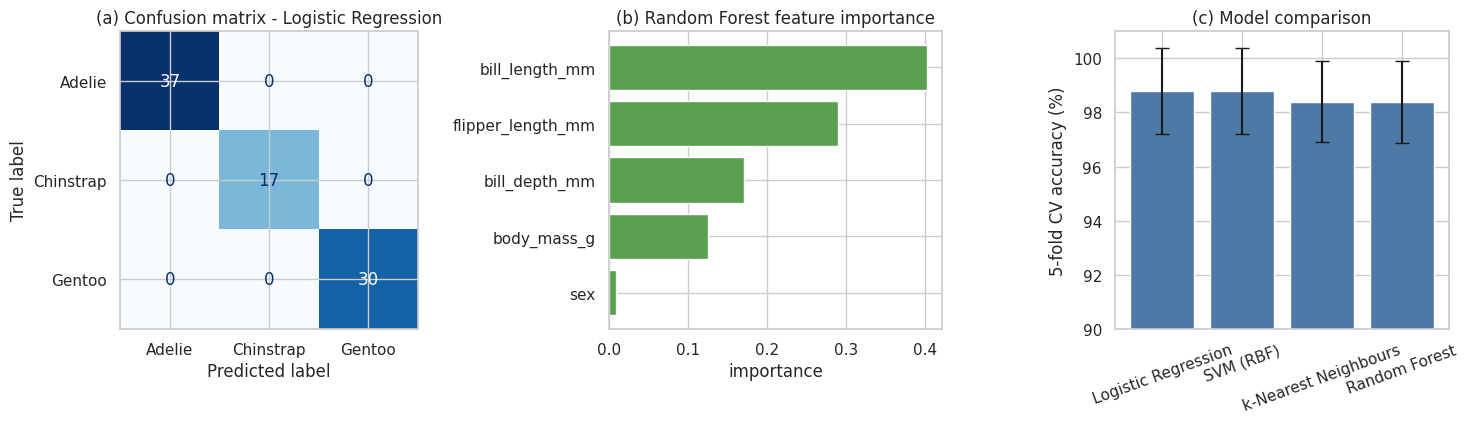

In [34]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

X = df_clean[num_cols + ['sex']].copy(); X['sex'] = X['sex'].map({'Female': 0, 'Male': 1}); y = df_clean['species']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('Train size:', Xtr.shape, '| Test size:', Xte.shape)
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'k-Nearest Neighbours': make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
    'SVM (RBF)': make_pipeline(StandardScaler(), SVC()),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
}
cv = StratifiedKFold(5, shuffle=True, random_state=42)
res = []
for n, mdl in models.items():
    sc = cross_val_score(mdl, Xtr, ytr, cv=cv)
    mdl.fit(Xtr, ytr)
    res.append(dict(model=n, cv_mean=round(sc.mean(), 4), cv_std=round(sc.std(), 4), test_accuracy=round(accuracy_score(yte, mdl.predict(Xte)), 4)))
res = pd.DataFrame(res).sort_values('cv_mean', ascending=False)
print(res.to_string(index=False)); tbl(res, 'model_comparison', index=False)
best = res.iloc[0]['model']; print('\nBest model by CV accuracy:', best)
pred = models[best].predict(Xte)
print(classification_report(yte, pred))
rf = models['Random Forest']
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
print('Random Forest feature importances:'); print(imp.round(3).sort_values(ascending=False).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ConfusionMatrixDisplay(confusion_matrix(yte, pred, labels=list(PAL)), display_labels=list(PAL)).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'(a) Confusion matrix - {best}')
axes[1].barh(imp.index, imp.values, color='#59A14F'); axes[1].set_title('(b) Random Forest feature importance'); axes[1].set_xlabel('importance')
axes[2].bar(res.model, res.cv_mean * 100, yerr=res.cv_std * 100, capsize=5, color='#4E79A7')
axes[2].set_ylim(90, 101); axes[2].set_ylabel('5-fold CV accuracy (%)'); axes[2].set_title('(c) Model comparison'); axes[2].tick_params(axis='x', rotation=20)
save('fig22_ml_results')

In [35]:
df_clean.to_csv('data/penguins_clean.csv', index=False)
print('Saved cleaned data -> data/penguins_clean.csv', df_clean.shape)
print('Figures generated:', len([f for f in os.listdir('figures') if f.endswith('.png')]))

Saved cleaned data -> data/penguins_clean.csv (333, 7)
Figures generated: 22
